In [1]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import MMA as Optimizer
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
for itr in range(ITR_MAX+1):
    f, gradf = sens.compute_obj_sens(x)
    g, gradg = volume_constraint(x)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 2.72e+02, g = -5.55e-17, norm_inf_x = 5.0e-02
1 iters, f = 1.79e+02, g = -4.06e-03, norm_inf_x = 5.0e-02
2 iters, f = 1.25e+02, g = -3.61e-03, norm_inf_x = 5.0e-02
3 iters, f = 9.21e+01, g = -2.77e-03, norm_inf_x = 5.0e-02
4 iters, f = 7.09e+01, g = -2.31e-03, norm_inf_x = 5.0e-02
5 iters, f = 5.66e+01, g = -2.01e-03, norm_inf_x = 5.0e-02
6 iters, f = 4.62e+01, g = -1.84e-03, norm_inf_x = 5.0e-02
7 iters, f = 3.91e+01, g = -1.27e-03, norm_inf_x = 5.0e-02
8 iters, f = 3.39e+01, g = -1.07e-03, norm_inf_x = 5.0e-02
9 iters, f = 2.99e+01, g = -1.04e-03, norm_inf_x = 5.0e-02
10 iters, f = 2.65e+01, g = -1.09e-03, norm_inf_x = 5.0e-02
11 iters, f = 2.35e+01, g = -1.15e-03, norm_inf_x = 5.0e-02
12 iters, f = 2.08e+01, g = -1.25e-03, norm_inf_x = 5.0e-02
13 iters, f = 1.84e+01, g = -1.28e-03, norm_inf_x = 5.0e-02
14 iters, f = 1.64e+01, g = -1.27e-03, norm_inf_x = 5.0e-02
15 iters, f = 1.54e+01, g = -1.22e-03, norm_inf_x = 5.0e-02
16 iters, f = 1.46e+01, g = -1.03e-03, norm_inf_x 

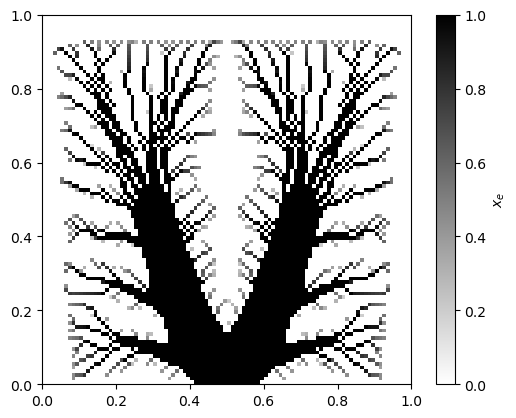

In [2]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label='$x_e$')

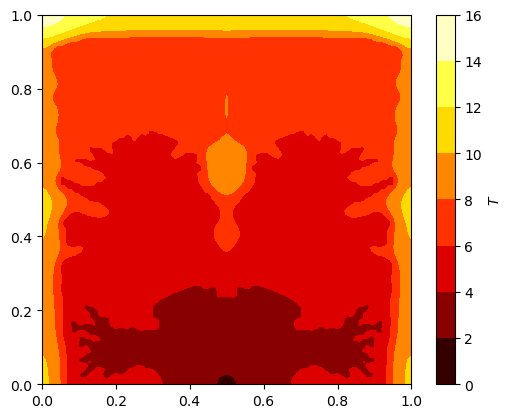

In [3]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [4]:
import numpy as np
from scipy import sparse
def density_filter(n1, n2, r):
    x_p, y_p = np.meshgrid(np.arange(n1), np.arange(n2))
    points = np.c_[x_p.ravel(), y_p.ravel()] # x,y座標を行方向に連結
    dx = points[:, 0][:, None]-points[:, 0] # x方向の差
    dy = points[:, 1][:, None]-points[:, 1] # y方向の差
    distMat = np.sqrt(dx**2+dy**2) # 各要素間のユークリッド距離
    mask = distMat <= r # フィルタ半径r以下の距離にある要素を抽出
    iH, jH = np.nonzero(mask) # 対応する行・列インデックス
    sH = r-distMat[mask]
    H = sparse.coo_matrix((sH, (iH, jH)), shape=(n1*n2, n1*n2))
    Hs = np.array(H.sum(1)).flatten()
    return H, Hs

In [5]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import MMA as Optimizer
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
H, Hs = density_filter(sens.n1, sens.n2, r) # 密度フィルタ
for itr in range(ITR_MAX+1):
    x_denf = H.dot(x)/Hs # 密度フィルタ後の設計変数
    f, gradf_fil = sens.compute_obj_sens(x_denf)
    g, gradg_fil = volume_constraint(x_denf)
    gradf = H@(gradf_fil/Hs) # 微分の連鎖律による目的関数の感度
    gradg = (H@(gradg_fil/Hs).T).T # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 2.72e+02, g = -5.55e-17, norm_inf_x = 5.0e-02
1 iters, f = 1.79e+02, g = -4.06e-03, norm_inf_x = 5.0e-02
2 iters, f = 1.25e+02, g = -3.61e-03, norm_inf_x = 5.0e-02
3 iters, f = 9.21e+01, g = -2.76e-03, norm_inf_x = 5.0e-02
4 iters, f = 7.09e+01, g = -2.29e-03, norm_inf_x = 5.0e-02
5 iters, f = 5.65e+01, g = -1.97e-03, norm_inf_x = 5.0e-02
6 iters, f = 4.62e+01, g = -1.72e-03, norm_inf_x = 5.0e-02
7 iters, f = 3.91e+01, g = -1.13e-03, norm_inf_x = 5.0e-02
8 iters, f = 3.40e+01, g = -9.46e-04, norm_inf_x = 5.0e-02
9 iters, f = 3.01e+01, g = -9.33e-04, norm_inf_x = 5.0e-02
10 iters, f = 2.68e+01, g = -9.63e-04, norm_inf_x = 5.0e-02
11 iters, f = 2.39e+01, g = -1.05e-03, norm_inf_x = 5.0e-02
12 iters, f = 2.12e+01, g = -1.12e-03, norm_inf_x = 5.0e-02
13 iters, f = 1.89e+01, g = -1.09e-03, norm_inf_x = 5.0e-02
14 iters, f = 1.69e+01, g = -1.00e-03, norm_inf_x = 5.0e-02
15 iters, f = 1.61e+01, g = -8.75e-04, norm_inf_x = 5.0e-02
16 iters, f = 1.55e+01, g = -7.30e-04, norm_inf_x 

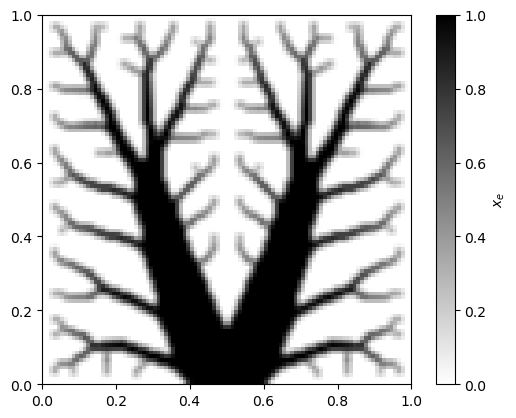

In [6]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_denf.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label='$x_e$')

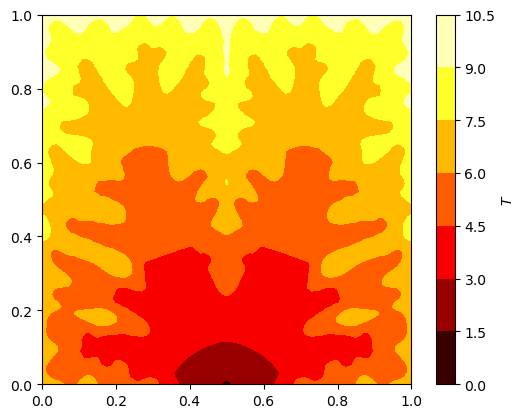

In [7]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [8]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta = 0.5 # しきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
fil = Projection(sens.n1, sens.n2, r, eta, beta0) # ヘビサイドプロジェクション
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x) # 密度フィルタ・ヘビサイドプロジェクション後の設計変数
    m_nd = fil.grayscale_indicator(x_proj) # グレースケール指標
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj) # 微分の連鎖律による目的関数の感度
    gradg = fil.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 3.11e+02, g = -1.36e-02, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 1.94e+02, g = -4.19e-03, norm_inf_x = 5.0e-02, m_nd = 82.42
2 iters, f = 1.31e+02, g = -3.19e-03, norm_inf_x = 5.0e-02, m_nd = 80.82
3 iters, f = 9.43e+01, g = -2.42e-03, norm_inf_x = 5.0e-02, m_nd = 78.68
4 iters, f = 7.13e+01, g = -2.06e-03, norm_inf_x = 5.0e-02, m_nd = 76.08
5 iters, f = 5.61e+01, g = -1.84e-03, norm_inf_x = 5.0e-02, m_nd = 72.87
6 iters, f = 4.55e+01, g = -1.60e-03, norm_inf_x = 5.0e-02, m_nd = 69.23
7 iters, f = 3.84e+01, g = -1.09e-03, norm_inf_x = 5.0e-02, m_nd = 66.73
8 iters, f = 3.33e+01, g = -9.53e-04, norm_inf_x = 5.0e-02, m_nd = 64.22
9 iters, f = 2.95e+01, g = -8.97e-04, norm_inf_x = 5.0e-02, m_nd = 62.19
10 iters, f = 2.65e+01, g = -9.29e-04, norm_inf_x = 5.0e-02, m_nd = 60.00
11 iters, f = 2.39e+01, g = -9.48e-04, norm_inf_x = 5.0e-02, m_nd = 57.54
12 iters, f = 2.16e+01, g = -1.01e-03, norm_inf_x = 5.0e-02, m_nd = 54.56
13 iters, f = 1.94e+01, g = -1.09e-03, norm_inf_

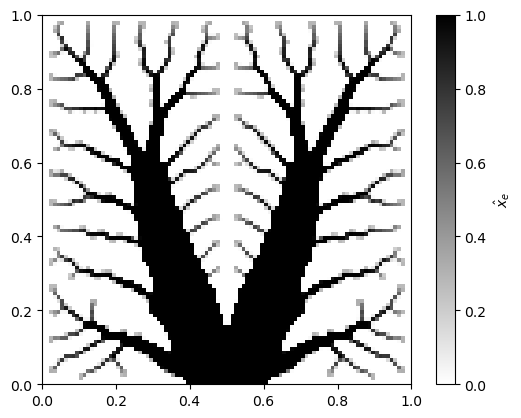

In [9]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_proj.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_e$')

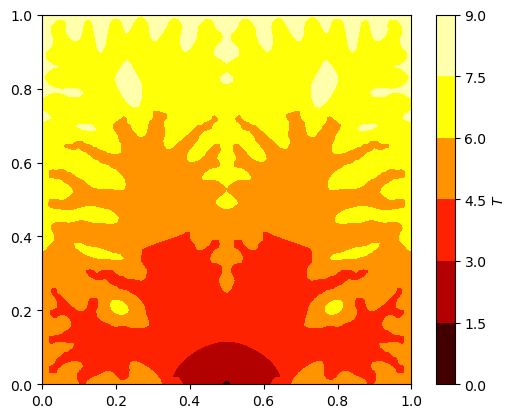

In [10]:
import matplotlib.pyplot as plt差し替え
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [11]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g, gradg_proj = volume_constraint(x_mid)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 5.01e+02, g = -1.36e-02, norm_inf_x = 6.4e-02, m_nd = 81.76
1 iters, f = 3.06e+02, g = -4.20e-03, norm_inf_x = 6.1e-02, m_nd = 82.42
2 iters, f = 2.01e+02, g = -3.19e-03, norm_inf_x = 6.4e-02, m_nd = 80.80
3 iters, f = 1.41e+02, g = -2.44e-03, norm_inf_x = 6.5e-02, m_nd = 78.57
4 iters, f = 1.03e+02, g = -2.09e-03, norm_inf_x = 7.7e-02, m_nd = 75.77
5 iters, f = 7.87e+01, g = -1.95e-03, norm_inf_x = 9.2e-02, m_nd = 72.11
6 iters, f = 6.18e+01, g = -1.82e-03, norm_inf_x = 1.0e-01, m_nd = 67.75
7 iters, f = 5.09e+01, g = -1.26e-03, norm_inf_x = 1.2e-01, m_nd = 64.88
8 iters, f = 4.31e+01, g = -1.11e-03, norm_inf_x = 1.3e-01, m_nd = 62.02
9 iters, f = 3.73e+01, g = -1.06e-03, norm_inf_x = 1.3e-01, m_nd = 59.64
10 iters, f = 3.28e+01, g = -1.07e-03, norm_inf_x = 1.6e-01, m_nd = 57.14
11 iters, f = 2.89e+01, g = -1.10e-03, norm_inf_x = 1.8e-01, m_nd = 54.30
12 iters, f = 2.54e+01, g = -1.16e-03, norm_inf_x = 2.1e-01, m_nd = 51.00
13 iters, f = 2.24e+01, g = -1.13e-03, norm_inf_

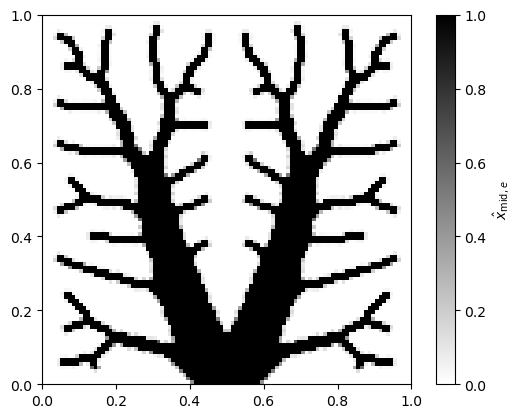

In [12]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

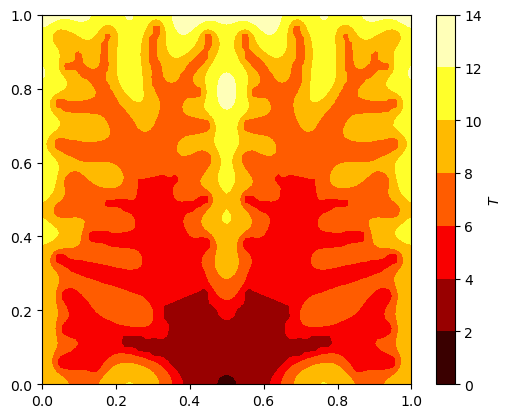

In [13]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [14]:
import numpy as np
from sens_heat import SubsetTemp as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
opt = Optimizer(x, 1) # MMAの初期化
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g, gradg_proj = volume_constraint(x_mid)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj) # 微分の連鎖律による制約関数の感度
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.40e+02, g = -1.36e-02, norm_inf_x = 6.4e-02, m_nd = 81.76
1 iters, f = 8.49e+01, g = -4.37e-03, norm_inf_x = 6.1e-02, m_nd = 82.35
2 iters, f = 5.52e+01, g = -3.71e-03, norm_inf_x = 6.6e-02, m_nd = 80.23
3 iters, f = 3.77e+01, g = -2.98e-03, norm_inf_x = 6.8e-02, m_nd = 77.20
4 iters, f = 2.67e+01, g = -2.58e-03, norm_inf_x = 8.4e-02, m_nd = 73.07
5 iters, f = 1.96e+01, g = -2.24e-03, norm_inf_x = 8.9e-02, m_nd = 67.98
6 iters, f = 1.47e+01, g = -1.95e-03, norm_inf_x = 9.8e-02, m_nd = 61.79
7 iters, f = 1.17e+01, g = -1.18e-03, norm_inf_x = 1.2e-01, m_nd = 58.54
8 iters, f = 9.55e+00, g = -9.94e-04, norm_inf_x = 1.4e-01, m_nd = 55.46
9 iters, f = 7.96e+00, g = -9.28e-04, norm_inf_x = 1.6e-01, m_nd = 52.21
10 iters, f = 6.73e+00, g = -8.88e-04, norm_inf_x = 1.8e-01, m_nd = 48.86
11 iters, f = 5.76e+00, g = -8.62e-04, norm_inf_x = 2.1e-01, m_nd = 45.47
12 iters, f = 4.97e+00, g = -8.18e-04, norm_inf_x = 2.2e-01, m_nd = 41.97
13 iters, f = 4.31e+00, g = -7.71e-04, norm_inf_

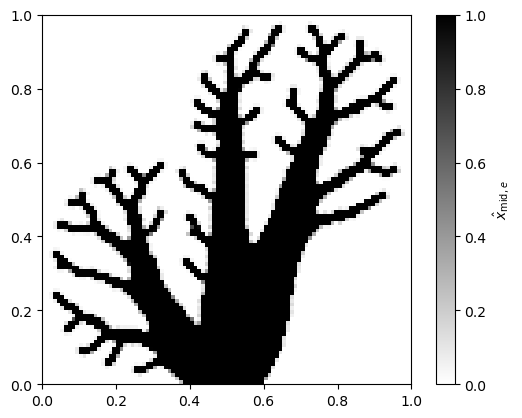

In [15]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

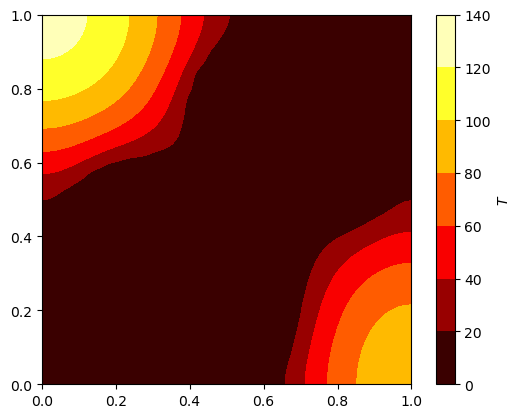

In [16]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [17]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import MMA as Optimizer
from filtering import Projection, MaxLength
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
r_ml = 8.0 # 最大寸法制約用無次元フィルタ半径
b_max = 3.0 # 最大寸法(最大幅/2)
p = 16 # 最大寸法制約用Pノルムパラメータ
opt = Optimizer(x, 2) # MMAの初期化: 制約2つ
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
def max_length_constraint(x, p, alpha):
    g = np.array([(np.sum(x**p)/len(x))**(1/p)/alpha-1]) # 最大寸法制約の関数
    gradg = np.array((np.sum(x**p)/len(x))**(1/p-1)*x**(p-1))[None,:]/(alpha*len(x)) # 最大寸法制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
fil_ml = MaxLength(sens.n1, sens.n2, r_ml, b_max) # 最大寸法制約用フィルタ
alpha = fil_ml.get_alpha() # 最大寸法制約における材料占有率
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    x_ml = fil_ml.apply(x_mid) # 最大寸法制約で用いるフィルタ後の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g1, gradg1_proj = volume_constraint(x_mid)
    g2, gradg2_ml = max_length_constraint(x_ml, p, alpha)
    gradg2_proj = fil_ml.modify_sensitivity_gradgi(gradg2_ml)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg1 = fil_mid.modify_sensitivity_gradgi(gradg1_proj) # 微分の連鎖律による制約関数1の感度
    gradg2 = fil_mid.modify_sensitivity_gradgi(gradg2_proj) # 微分の連鎖律による制約関数2の感度
    g, gradg = np.array([g1[0], g2[0]]), np.concatenate([gradg1, gradg2])
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, g2 = {g[1]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 5.01e+02, g1 = -1.36e-02, g2 = -3.85e-01, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 3.06e+02, g1 = -4.20e-03, g2 = -3.05e-01, norm_inf_x = 5.0e-02, m_nd = 82.42
2 iters, f = 2.01e+02, g1 = -3.19e-03, g2 = -2.20e-01, norm_inf_x = 5.0e-02, m_nd = 80.80
3 iters, f = 1.41e+02, g1 = -2.44e-03, g2 = -1.29e-01, norm_inf_x = 5.0e-02, m_nd = 78.57
4 iters, f = 1.03e+02, g1 = -2.09e-03, g2 = -3.80e-02, norm_inf_x = 5.0e-02, m_nd = 75.77
5 iters, f = 7.97e+01, g1 = -2.22e-03, g2 = 1.86e-02, norm_inf_x = 5.0e-02, m_nd = 73.48
6 iters, f = 6.67e+01, g1 = -2.04e-03, g2 = 2.62e-02, norm_inf_x = 5.0e-02, m_nd = 71.33
7 iters, f = 6.03e+01, g1 = -1.80e-03, g2 = 1.44e-02, norm_inf_x = 5.0e-02, m_nd = 71.05
8 iters, f = 5.50e+01, g1 = -1.54e-03, g2 = 2.12e-02, norm_inf_x = 5.0e-02, m_nd = 70.06
9 iters, f = 5.22e+01, g1 = -1.73e-03, g2 = 2.02e-02, norm_inf_x = 5.0e-02, m_nd = 69.60
10 iters, f = 4.97e+01, g1 = -1.77e-03, g2 = 2.30e-02, norm_inf_x = 5.0e-02, m_nd = 69.57
11 iters, f = 4

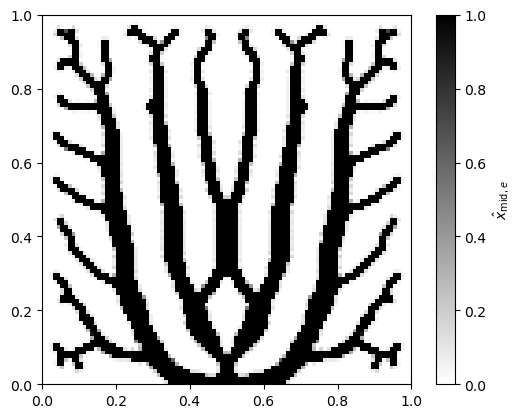

In [18]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

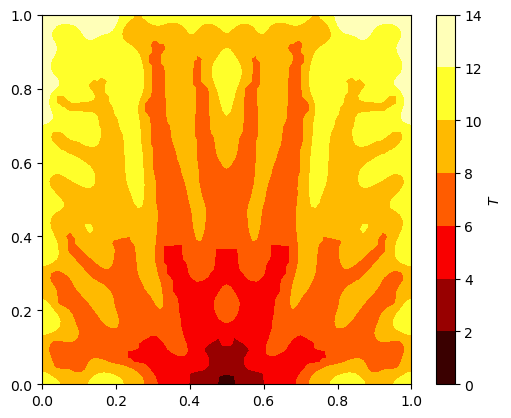

In [19]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [20]:
import numpy as np
from sens_heat import SensHeat as Sens
from optimizer import SLP as Optimizer
from filtering import Projection, MaxLength
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
r_ml = 8.0 # 最大寸法制約用無次元フィルタ半径
b_max = 3.0 # 最大寸法(最大幅/2)
p = 16 # 最大寸法制約用Pノルムパラメータ
opt = Optimizer(x, 2) # MMAの初期化: 制約2つ
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
def max_length_constraint(x, p, alpha):
    g = np.array([(np.sum(x**p)/len(x))**(1/p)/alpha-1]) # 最大寸法制約の関数
    gradg = np.array((np.sum(x**p)/len(x))**(1/p-1)*x**(p-1))[None,:]/(alpha*len(x)) # 最大寸法制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
fil_ml = MaxLength(sens.n1, sens.n2, r_ml, b_max) # 最大寸法制約用フィルタ
alpha = fil_ml.get_alpha() # 最大寸法制約における材料占有率
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    x_ml = fil_ml.apply(x_mid) # 最大寸法制約で用いるフィルタ後の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g1, gradg1_proj = volume_constraint(x_mid)
    g2, gradg2_ml = max_length_constraint(x_ml, p, alpha)
    gradg2_proj = fil_ml.modify_sensitivity_gradgi(gradg2_ml)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg1 = fil_mid.modify_sensitivity_gradgi(gradg1_proj) # 微分の連鎖律による制約関数1の感度
    gradg2 = fil_mid.modify_sensitivity_gradgi(gradg2_proj) # 微分の連鎖律による制約関数2の感度
    g, gradg = np.array([g1[0], g2[0]]), np.concatenate([gradg1, gradg2])
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, g2 = {g[1]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 5.01e+02, g1 = -1.36e-02, g2 = -3.85e-01, norm_inf_x = 2.5e-02, m_nd = 81.76
1 iters, f = 3.86e+02, g1 = 1.23e-04, g2 = -3.42e-01, norm_inf_x = 2.5e-02, m_nd = 83.83
2 iters, f = 3.05e+02, g1 = 1.17e-04, g2 = -3.06e-01, norm_inf_x = 3.0e-02, m_nd = 83.31
3 iters, f = 2.35e+02, g1 = 1.33e-04, g2 = -2.54e-01, norm_inf_x = 3.6e-02, m_nd = 82.30
4 iters, f = 1.78e+02, g1 = 1.63e-04, g2 = -1.87e-01, norm_inf_x = 4.3e-02, m_nd = 80.64
5 iters, f = 1.32e+02, g1 = 2.01e-04, g2 = -1.11e-01, norm_inf_x = 5.0e-02, m_nd = 78.74
6 iters, f = 9.88e+01, g1 = 2.17e-04, g2 = -2.18e-02, norm_inf_x = 5.0e-02, m_nd = 76.08
7 iters, f = 7.76e+01, g1 = 2.12e-04, g2 = 3.10e-02, norm_inf_x = 5.0e-02, m_nd = 74.69
8 iters, f = 6.57e+01, g1 = 1.84e-04, g2 = 2.76e-02, norm_inf_x = 5.0e-02, m_nd = 72.91
9 iters, f = 6.03e+01, g1 = 1.44e-04, g2 = 8.81e-03, norm_inf_x = 5.0e-02, m_nd = 72.65
10 iters, f = 5.53e+01, g1 = 1.37e-04, g2 = 6.66e-03, norm_inf_x = 5.0e-02, m_nd = 71.60
11 iters, f = 5.21e+01,

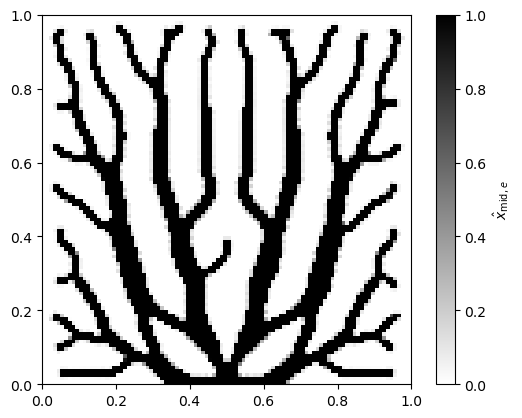

In [21]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_mid.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

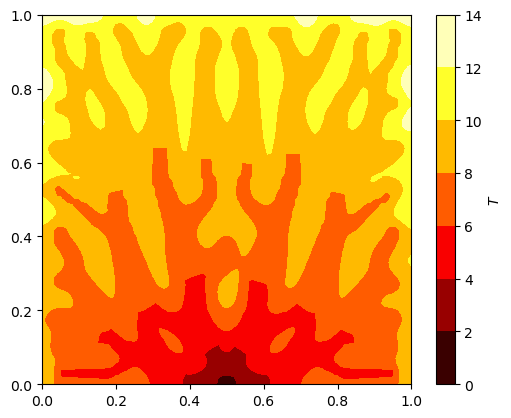

In [22]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1+1), np.linspace(0, sens.L2, sens.n2+1)
X, Y = np.meshgrid(x_p, y_p)
plt.contourf(X, Y, sens.d.reshape((sens.n2+1, sens.n1+1)), cmap='hot')
plt.gca().set_aspect('equal')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')

In [23]:
import numpy as np
from sens_heat import SensHeatSym as Sens
from optimizer import SLP as Optimizer
from filtering import Projection, MaxLength
ITR_MAX = 150 # 最大反復回数
X_TOL = 1e-4 # 設計変数の収束基準
V_MAX = 0.3 # 設計領域の体積比率
sens = Sens() # 熱伝導場の物理モデルの初期化
x = np.full(sens.n1*sens.n2, V_MAX) # 設計変数の初期値
r = 2.0 # 無次元フィルタ半径
eta0 = 0.25 # 基準となるしきい値パラメータ
eta_dil = eta0 # 太くなるしきい値パラメータ
eta_mid = 0.5 # 中間のしきい値パラメータ
eta_ero = 1-eta0 # 細くなるしきい値パラメータ
beta0 = 1 # 初期急峻化パラメータ
r_ml = 8.0 # 最大寸法制約用無次元フィルタ半径
b_max = 3.0 # 最大寸法(最大幅/2)
p = 16 # 最大寸法制約用Pノルムパラメータ
opt = Optimizer(x, 2) # MMAの初期化: 制約2つ
def volume_constraint(x): 
    g = np.array([x.sum()/len(x)-V_MAX]) # 体積制約の関数
    gradg = np.array(np.ones_like(x))[None,:]/len(x) # 体積制約の勾配
    return g, gradg 
def max_length_constraint(x, p, alpha):
    g = np.array([(np.sum(x**p)/len(x))**(1/p)/alpha-1]) # 最大寸法制約の関数
    gradg = np.array((np.sum(x**p)/len(x))**(1/p-1)*x**(p-1))[None,:]/(alpha*len(x)) # 最大寸法制約の勾配
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]] # ロバストトポロジー最適化用ヘビサイドプロジェクション
fil_dil, fil_mid, fil_ero = filters
fil_ml = MaxLength(sens.n1, sens.n2, r_ml, b_max) # 最大寸法制約用フィルタ
alpha = fil_ml.get_alpha() # 最大寸法制約における材料占有率
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters] # 太・中間・細の設計変数
    x_ml = fil_ml.apply(x_mid) # 最大寸法制約で用いるフィルタ後の設計変数
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx]) # 最悪値の目的関数とその感度を取得
    g1, gradg1_proj = volume_constraint(x_mid)
    g2, gradg2_ml = max_length_constraint(x_ml, p, alpha)
    gradg2_proj = fil_ml.modify_sensitivity_gradgi(gradg2_ml)
    fil_obj = filters[idx]
    gradf = fil_obj.modify_sensitivity_gradf(gradf_proj) # 最悪値での微分の連鎖律による目的関数の感度
    gradg1 = fil_mid.modify_sensitivity_gradgi(gradg1_proj) # 微分の連鎖律による制約関数1の感度
    gradg2 = fil_mid.modify_sensitivity_gradgi(gradg2_proj) # 微分の連鎖律による制約関数2の感度
    g, gradg = np.array([g1[0], g2[0]]), np.concatenate([gradg1, gradg2])
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g1 = {g[0]:.2e}, g2 = {g[1]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 2.50e+02, g1 = -1.36e-02, g2 = -3.85e-01, norm_inf_x = 2.5e-02, m_nd = 81.76
1 iters, f = 1.93e+02, g1 = 1.23e-04, g2 = -3.42e-01, norm_inf_x = 2.5e-02, m_nd = 83.83
2 iters, f = 1.52e+02, g1 = 1.17e-04, g2 = -3.06e-01, norm_inf_x = 3.0e-02, m_nd = 83.31
3 iters, f = 1.17e+02, g1 = 1.33e-04, g2 = -2.54e-01, norm_inf_x = 3.6e-02, m_nd = 82.30
4 iters, f = 8.88e+01, g1 = 1.63e-04, g2 = -1.87e-01, norm_inf_x = 4.3e-02, m_nd = 80.64
5 iters, f = 6.62e+01, g1 = 2.01e-04, g2 = -1.12e-01, norm_inf_x = 5.0e-02, m_nd = 78.74
6 iters, f = 4.94e+01, g1 = 2.17e-04, g2 = -2.18e-02, norm_inf_x = 5.0e-02, m_nd = 76.07
7 iters, f = 3.88e+01, g1 = 2.12e-04, g2 = 3.06e-02, norm_inf_x = 5.0e-02, m_nd = 74.68
8 iters, f = 3.27e+01, g1 = 1.84e-04, g2 = 2.58e-02, norm_inf_x = 5.0e-02, m_nd = 72.84
9 iters, f = 2.98e+01, g1 = 1.44e-04, g2 = 7.49e-03, norm_inf_x = 5.0e-02, m_nd = 72.51
10 iters, f = 2.71e+01, g1 = 1.39e-04, g2 = 5.76e-03, norm_inf_x = 5.0e-02, m_nd = 71.37
11 iters, f = 2.52e+01,

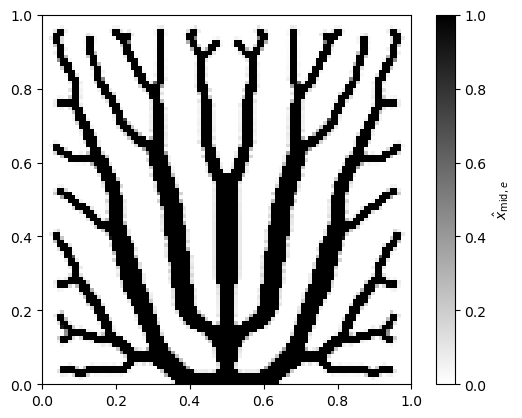

In [24]:
import matplotlib.pyplot as plt
x_mid_full = np.hstack([np.flip(x_mid.reshape((sens.n2, sens.n1)), axis=1), x_mid.reshape((sens.n2, sens.n1))])
plt.imshow(x_mid_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[0, 2*sens.L1, 0, sens.L2])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

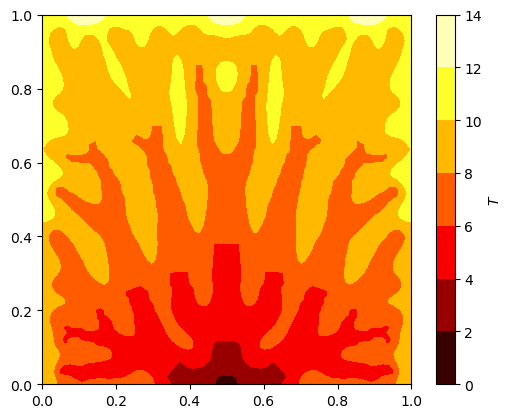

In [25]:
import matplotlib.pyplot as plt
d_reshaped = sens.d.reshape((sens.n2+1, sens.n1+1))
d_full = np.hstack([np.flip(d_reshaped, axis=1), d_reshaped])
x_p_full = np.linspace(0, 2*sens.L1, 2*sens.n1+2)
y_p = np.linspace(0, sens.L2, sens.n2+1)
X_full, Y = np.meshgrid(x_p_full, y_p)
plt.contourf(X_full, Y, d_full, cmap='hot')
plt.colorbar(label='$T$')
plt.gca().set_aspect('equal')